In [1]:
# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load the advertising dataset
df = pd.read_csv("Advertising.csv")

# Display the first five rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (200, 4)

Column Names:
['TV', 'Radio', 'Newspaper', 'Sales']

Data Types:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [5]:
# Display descriptive statistics
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Display the cleaned column names
print(df.columns.tolist())

['TV', 'Radio', 'Newspaper', 'Sales']


In [7]:
# Remove unnecessary index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Updated Shape:", df.shape)
print("Columns:", df.columns.tolist())

Updated Shape: (200, 4)
Columns: ['TV', 'Radio', 'Newspaper', 'Sales']


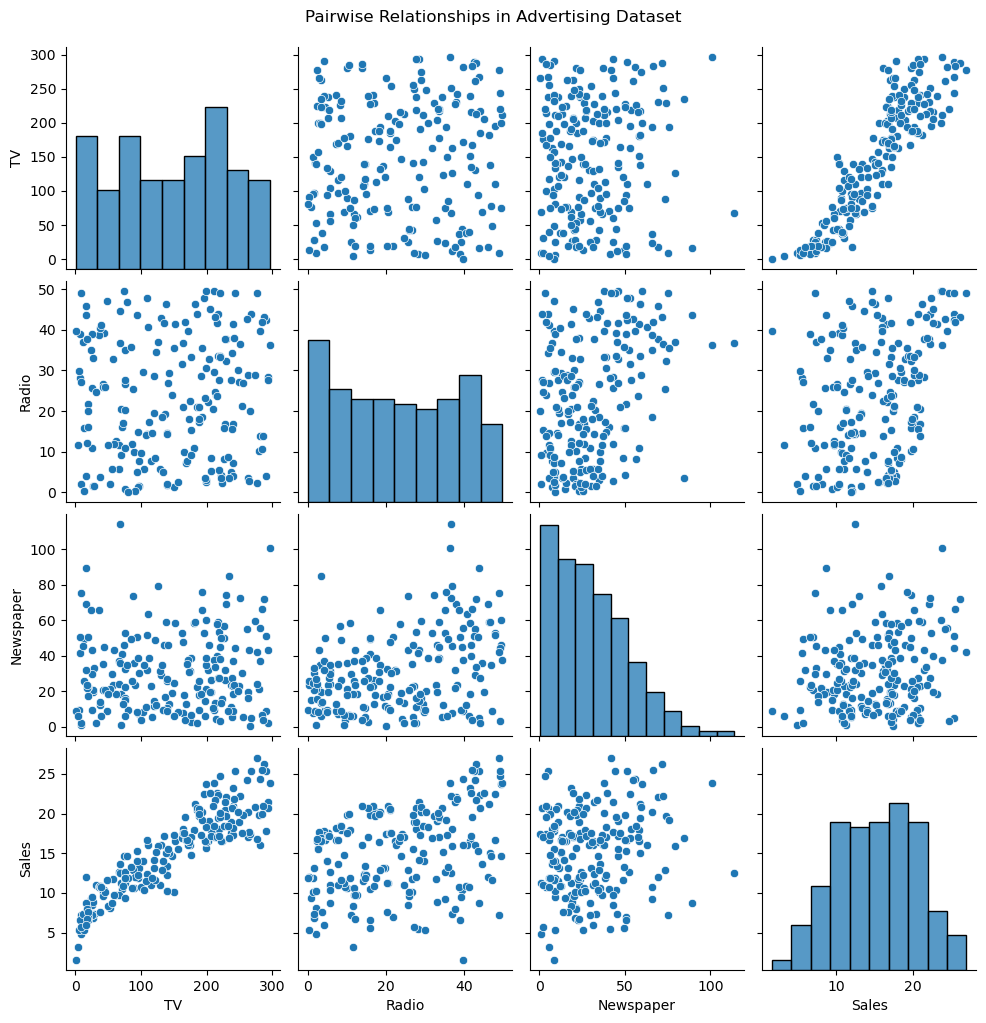

In [8]:
# Create pairplot to visualize relationships among advertising channels and sales
sns.pairplot(df)

plt.suptitle(
    "Pairwise Relationships in Advertising Dataset",
    y=1.02
)

plt.show()

## Pairplot Observation

The pairplot provides an overview of the relationships between advertising expenditure and sales. Among the three advertising channels, TV and Radio spending appear to have clearer positive relationships with sales, while the relationship between Newspaper spending and sales appears comparatively weaker.


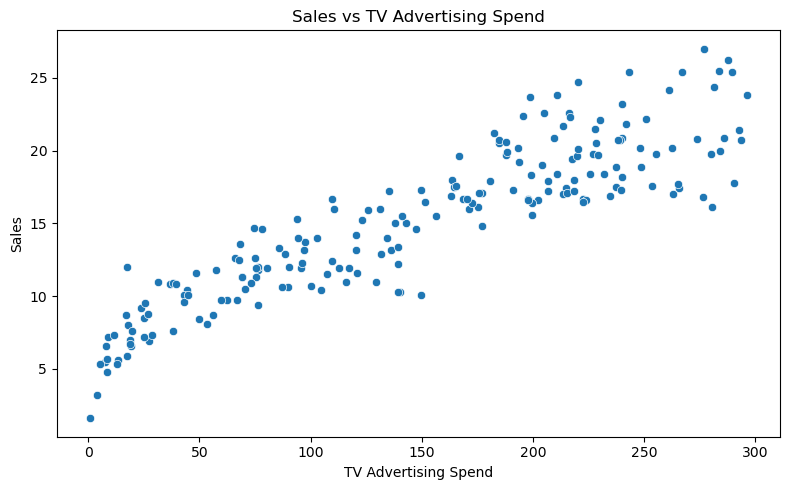

In [9]:
# Plot the relationship between TV advertising spend and sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising Spend")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a clear positive relationship between TV advertising expenditure and sales. As TV advertising spending increases, sales generally tend to increase as well.


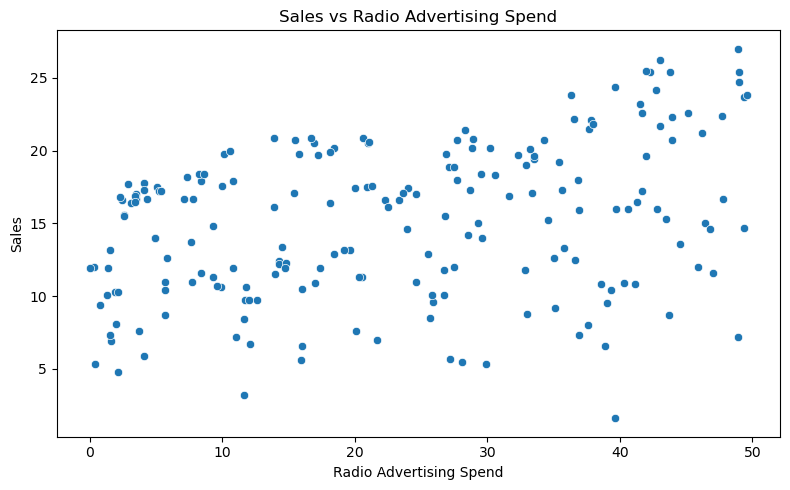

In [10]:
# Plot the relationship between Radio advertising spend and sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Sales vs Radio Advertising Spend")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Observation

The plot indicates a positive relationship between Radio advertising expenditure and sales. The relationship appears relatively strong, suggesting that Radio advertising may have a meaningful association with product sales.


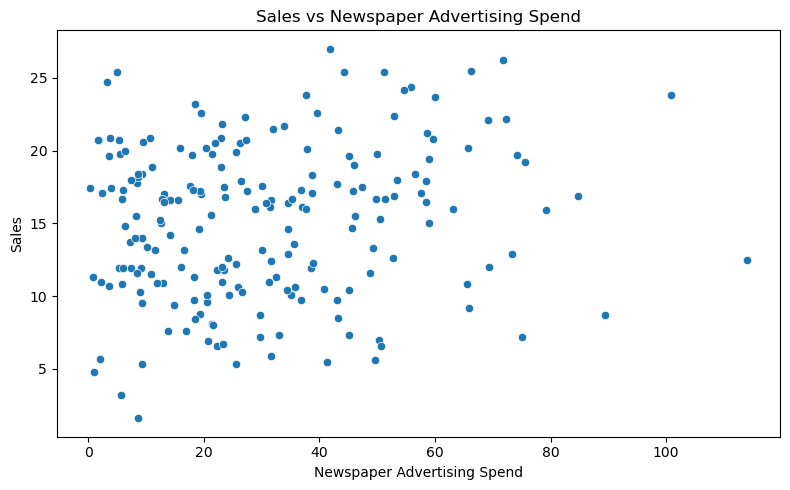

In [11]:
# Plot the relationship between Newspaper advertising spend and sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Sales vs Newspaper Advertising Spend")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

### Observation

The relationship between Newspaper advertising expenditure and sales appears weaker compared with the relationships observed for TV and Radio advertising. This suggests that Newspaper spending may have a smaller contribution to predicting sales in this dataset.


In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
correlation_matrix

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


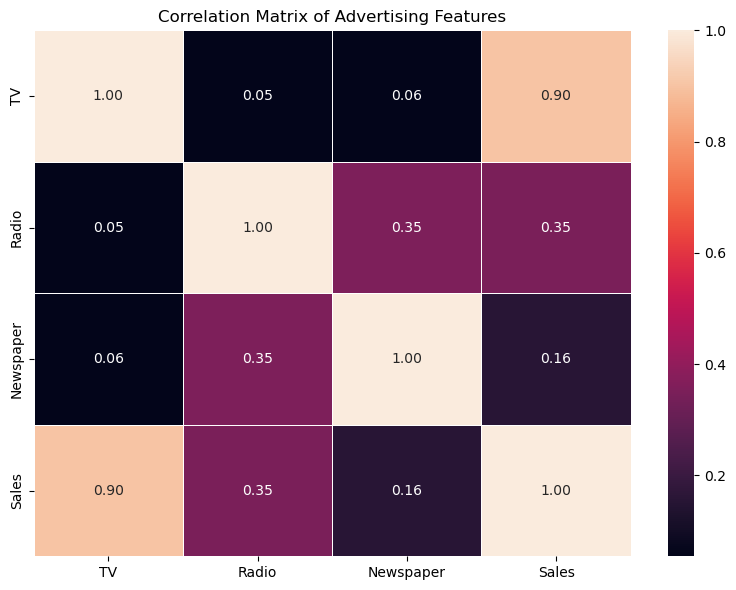

In [13]:
# Visualize correlations using a heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Advertising Features")
plt.tight_layout()
plt.show()

## Correlation Heatmap Observation

The correlation matrix shows the strength of the relationships between advertising expenditure and sales. A stronger positive correlation indicates that higher advertising spending tends to be associated with higher sales.

TV and Radio show stronger relationships with Sales than Newspaper in this dataset. However, correlation measures association and does not by itself prove that changes in advertising spending directly cause changes in sales.


In [14]:
# Define input features
X = df[["TV", "Radio", "Newspaper"]]

# Define target variable
y = df["Sales"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (200, 3)
Target shape: (200,)


In [15]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


In [16]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test data
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [17]:
# Create the Random Forest Regressor
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Generate predictions
rf_predictions = random_forest_model.predict(X_test)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [18]:
# Function to calculate regression metrics

def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    return mae, rmse, r2

In [19]:
# Evaluate Linear Regression
linear_mae, linear_rmse, linear_r2 = evaluate_model(
    y_test,
    linear_predictions
)

# Evaluate Random Forest
rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_predictions
)

print("Linear Regression")
print("-----------------")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

print("\nRandom Forest Regressor")
print("----------------------")
print("MAE :", round(rf_mae, 3))
print("RMSE:", round(rf_rmse, 3))
print("R²  :", round(rf_r2, 3))

Linear Regression
-----------------
MAE : 1.275
RMSE: 1.705
R²  : 0.906

Random Forest Regressor
----------------------
MAE : 0.914
RMSE: 1.183
R²  : 0.955


## Best Model Selection

Two regression models were evaluated for predicting product sales: Linear Regression and Random Forest Regressor.

Linear Regression achieved an MAE of **1.275**, an RMSE of **1.705**, and an R² score of **0.906**. Random Forest Regressor achieved an MAE of **0.914**, an RMSE of **1.183**, and an R² score of **0.955**.

Random Forest Regressor performed better across all three evaluation metrics. It produced lower MAE and RMSE values, indicating smaller prediction errors, while its higher R² score shows that it explains a greater proportion of the variation in sales.

Therefore, **Random Forest Regressor is selected as the best-performing model for this project**.


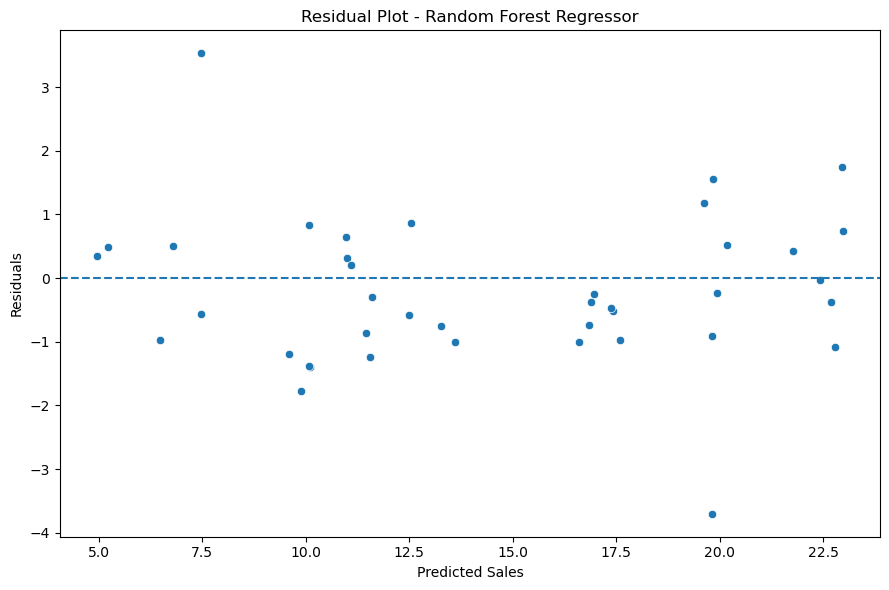

In [20]:
# Calculate residuals for the best-performing model
residuals = y_test - rf_predictions

# Plot residuals
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=rf_predictions,
    y=residuals
)

# Add a horizontal reference line at zero
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Random Forest Regressor")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

## Residual Plot Observation

The residual plot shows that the prediction errors are distributed around the zero reference line without a clear continuous trend. This suggests that the Random Forest model is capturing most of the underlying relationship between advertising expenditure and sales.

However, a few relatively large positive and negative residuals can be observed, indicating that the model makes larger errors for some observations. Overall, there is no strong systematic pattern visible in the residuals, although the error distribution is not perfectly uniform.


In [21]:
# Get feature importance from the trained Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Display feature importance
feature_importance

,Feature,Importance
0,TV,0.844376
1,Radio,0.136431
2,Newspaper,0.019194


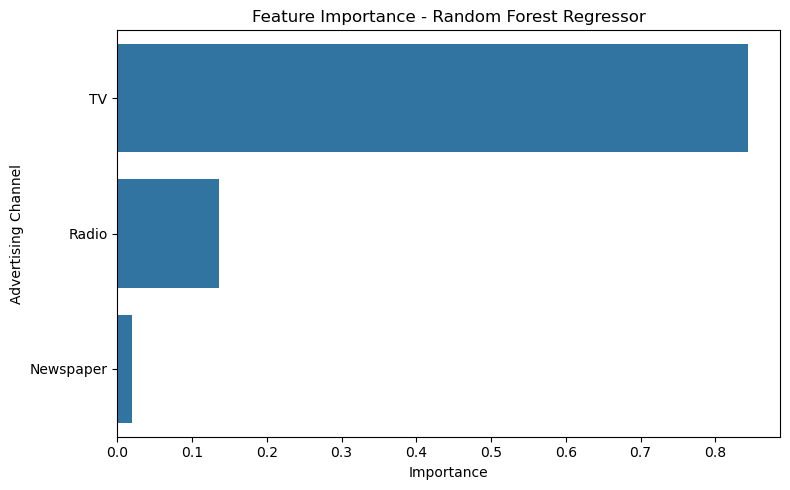

In [22]:
# Visualize feature importance

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.tight_layout()
plt.show()

## Advertising Channel Impact

The feature importance analysis shows that **TV advertising has the highest impact on predicted sales** among the three advertising channels. Radio has the second-highest importance, while Newspaper has the lowest importance in the Random Forest model.

This suggests that TV advertising expenditure provides the most useful information for predicting sales in this dataset. However, feature importance represents the model's predictive contribution and should not be interpreted as proof that increasing a particular advertising channel will directly cause higher sales.


## Final Conclusion

This project developed a machine learning regression model to predict product sales using advertising expenditure across TV, Radio, and Newspaper channels.

The dataset was first explored using descriptive statistics, pairwise visualizations, individual scatter plots, and a correlation heatmap. These analyses helped identify relationships between advertising expenditure and sales.

The data was divided into training and testing sets using an 80/20 split. Linear Regression was used as the baseline model, while Random Forest Regressor was trained as an additional model.

Linear Regression achieved an MAE of **1.275**, an RMSE of **1.705**, and an R² score of **0.906**. Random Forest Regressor performed better, achieving an MAE of **0.914**, an RMSE of **1.183**, and an R² score of **0.955**.

Based on these evaluation metrics, **Random Forest Regressor was selected as the best-performing model** because it produced lower prediction errors and a higher R² score.

The residual analysis showed that the prediction errors were distributed around the zero reference line without a strong systematic pattern, although a few larger errors were present.

Feature importance analysis showed that **TV advertising had the highest predictive importance**, followed by Radio and Newspaper. Therefore, TV advertising provided the strongest predictive signal for sales within this dataset.

Overall, this project demonstrates how exploratory data analysis, regression models, evaluation metrics, residual analysis, and feature importance can be combined to understand and predict product sales from advertising expenditure.
